<a href="https://colab.research.google.com/github/Divij6/MachineLearningPractice/blob/main/BackPropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sympy import diff, symbols

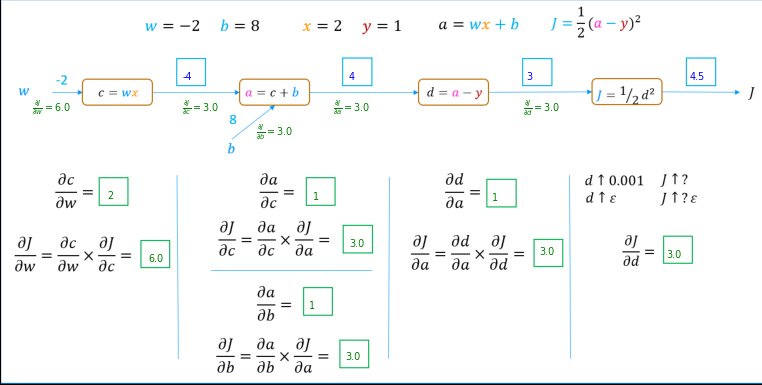

### Forward propagation
The calculations in the forward path are the ones you have recently learned for neural networks.

In [3]:
# Inputs and parameters
x = 2
w = -2
b = 8
y = 1
# calculate per step values
c = w * x
a = c + b
d = a - y
J = d**2/2
print(f"J={J}, d={d}, a={a}, c={c}")

J=4.5, d=3, a=4, c=-4


In [4]:
d_epsilon = d + 0.001
J_epsilon = d_epsilon**2/2
k = (J_epsilon - J)/0.001   # difference divided by epsilon
print(f"J = {J}, J_epsilon = {J_epsilon}, dJ_dd ~= k = {k} ")

J = 4.5, J_epsilon = 4.5030005, dJ_dd ~= k = 3.0004999999997395 


### Backward propagation (Backprop)

### $\frac{\partial J}{\partial d}$

#### Arithmetically
Find $\frac{\partial J}{\partial d}$ by finding how $J$ changes as a result of a little change in $d$.

In [5]:
d_epsilon = d + 0.001
J_epsilon = d_epsilon**2/2
k = (J_epsilon - J)/0.001   # difference divided by epsilon
print(f"J = {J}, J_epsilon = {J_epsilon}, dJ_dd ~= k = {k} ")

J = 4.5, J_epsilon = 4.5030005, dJ_dd ~= k = 3.0004999999997395 


$\frac{\partial J}{\partial d}$ is 3, which is the value of $d$. Our result is not exactly $d$ because our epsilon value is not infinitesimally small.
#### Symbolically


In [6]:
sx,sw,sb,sy,sJ = symbols('x,w,b,y,J')
sa, sc, sd = symbols('a,c,d')
sJ = sd**2/2
sJ

d**2/2

In [7]:
sJ.subs([(sd,d)])

9/2

In [8]:
dJ_dd = diff(sJ, sd)
dJ_dd

d

So, $\frac{\partial J}{\partial d}$ = d. When $d=3$, $\frac{\partial J}{\partial d}$ = 3. This matches our arithmetic calculation above.

### $\frac{\partial J}{\partial a}$


#### Arithmetically

In [9]:
a_epsilon = a + 0.001         # a  plus a small value
d_epsilon = a_epsilon - y
k = (d_epsilon - d)/0.001   # difference divided by epsilon
print(f"d = {d}, d_epsilon = {d_epsilon}, dd_da ~= k = {k} ")

d = 3, d_epsilon = 3.0010000000000003, dd_da ~= k = 1.000000000000334 


Calculated arithmetically,  $\frac{\partial d}{\partial a} \approx 1$.
#### Symbolically

In [10]:
sd = sa - sy
sd

a - y

In [11]:
dd_da = diff(sd,sa)
dd_da

1

In [12]:
dJ_da = dd_da * dJ_dd
dJ_da

d

$d$ is 3 in this example so $\frac{\partial J}{\partial a} = 3$.

In [13]:
a_epsilon = a + 0.001
d_epsilon = a_epsilon - y
J_epsilon = d_epsilon**2/2
k = (J_epsilon - J)/0.001
print(f"J = {J}, J_epsilon = {J_epsilon}, dJ_da ~= k = {k} ")

J = 4.5, J_epsilon = 4.503000500000001, dJ_da ~= k = 3.0005000000006277 


### $\frac{\partial J}{\partial c}$,  $\frac{\partial J}{\partial b}$

In [14]:
# calculate the local derivatives da_dc, da_db
sa = sc + sb
sa

b + c

In [15]:
da_dc = diff(sa,sc)
da_db = diff(sa,sb)
print(da_dc, da_db)

1 1


In [16]:
dJ_dc = da_dc * dJ_da
dJ_db = da_db * dJ_da
print(f"dJ_dc = {dJ_dc},  dJ_db = {dJ_db}")

dJ_dc = d,  dJ_db = d


###  $\frac{\partial J}{\partial w}$

In [17]:
# calculate the local derivative
sc = sw * sx
sc

w*x

In [18]:
dc_dw = diff(sc,sw)
dc_dw

x

In [19]:
dJ_dw = dc_dw * dJ_dc
dJ_dw

d*x

In [20]:
print(f"dJ_dw = {dJ_dw.subs([(sd,d),(sx,x)])}")

dJ_dw = 2*d


$d=3$,  so $\frac{\partial J}{\partial w} = 6$ for our example.

In [21]:
J_epsilon = ((w+0.001)*x+b - y)**2/2
k = (J_epsilon - J)/0.001
print(f"J = {J}, J_epsilon = {J_epsilon}, dJ_dw ~= k = {k} ")

J = 4.5, J_epsilon = 4.506002, dJ_dw ~= k = 6.001999999999619 
